# 08 让组合"有道理"：错误重合诊断 + 分级筛查（MLP 初筛 → SVM 复核）

05、06 的组合没用，原因在语义上：
- 并行：两个模型看同样的材料、干同样的活，SVM 又更弱，平均只是掺噪声；
- 串行（MLP 隐藏层 → SVM）：MLP 最后一层本来就是在隐空间里画分界线，换成 SVM 等于换个人重做同一件事，手里的数据还更少。

这一份做两件事：
1. **诊断**：MLP 和 SVM 漏掉的欺诈是不是同一批？如果几乎重合，就从数据上证明了"两个模型看到的东西一样"。
2. **分级筛查（级联）**：第一级 MLP 看全部交易，阈值放低，只求不漏；第二级 SVM 只在第一级筛出来的少量可疑交易里复核。理由：
   - SVM 最大的问题是数据多了就慢，只能抽样；在可疑子集里数据很少，可以全部用上；
   - 子集里欺诈比例高得多，不平衡问题大大缓解；
   - 子集里都是"MLP 也拿不准"的难样本，正好让 SVM 发挥小样本、最大间隔的长处。

切分和 05~07 完全一样。所有阈值、参数都在验证集上选，测试集只在最后打分。

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import json
import time
import itertools
import warnings
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data-mining'
except ImportError:
    DATA_DIR = os.environ.get('CCFD_DATA_DIR', 'data')

train_df = pd.read_csv(f'{DATA_DIR}/train_scaled.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_scaled.csv')
feature_cols = [c for c in train_df.columns if c != 'Class']
X_test, y_test = test_df[feature_cols].values, test_df['Class'].values

row_id = pd.util.hash_pandas_object(train_df, index=False).values
uniq = pd.DataFrame({'row_id': row_id, 'Class': train_df['Class'].values}).drop_duplicates('row_id')
fit_ids, _ = train_test_split(uniq['row_id'], test_size=0.2, stratify=uniq['Class'], random_state=42)
is_fit = np.isin(row_id, fit_ids.values)
X_fit, y_fit = train_df.loc[is_fit, feature_cols].values, train_df.loc[is_fit, 'Class'].values
X_val, y_val = train_df.loc[~is_fit, feature_cols].values, train_df.loc[~is_fit, 'Class'].values
groups_fit = row_id[is_fit]

with open(f'{DATA_DIR}/svm_best.json') as f:
    svm_best = json.load(f)
print(f'拟合用 {len(y_fit)} 行，验证集 {len(y_val)} 行（欺诈 {y_val.sum()}），测试集 {len(y_test)} 行（欺诈 {y_test.sum()}）')
print('06 选出的 SVM 参数：', svm_best)

拟合用 159509 行，验证集 39882 行（欺诈 69），测试集 85416 行（欺诈 145）
06 选出的 SVM 参数： {'C': 100.0, 'gamma': 0.0001}


## 0. 训练两个单独模型（和 05、06 一样）

- MLP：30 → 64 → 32 → 1，用全部"拟合用"数据训练。
- SVM：06 调好的参数，用全部欺诈 + 2 万条正常样本训练。

阈值都在验证集上按 F1 最高来选。

In [3]:
def make_mlp():
    return MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=20, random_state=42)

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return thr[np.argmax(f1)]

def summary(name, y, score, threshold):
    pred = score >= threshold
    caught = int((pred & (y == 1)).sum())
    alarm = int((pred & (y == 0)).sum())
    return {'方案': name, 'AUPRC': average_precision_score(y, score), 'F1': f1_score(y, pred),
            '抓到': caught, '漏掉': int((y == 1).sum()) - caught, '误报': alarm,
            'Recall': caught / (y == 1).sum(), 'Precision': caught / max(caught + alarm, 1)}

mlp = make_mlp().fit(X_fit, y_fit)
p_val, p_test = mlp.predict_proba(X_val)[:, 1], mlp.predict_proba(X_test)[:, 1]

rng = np.random.default_rng(42)
svm_rows = np.concatenate([np.flatnonzero(y_fit == 1),
                           rng.choice(np.flatnonzero(y_fit == 0), 20000, replace=False)])
svm = SVC(kernel='rbf', C=svm_best['C'], gamma=svm_best['gamma'], class_weight='balanced', random_state=42)
svm.fit(X_fit[svm_rows], y_fit[svm_rows])
s_val, s_test = svm.decision_function(X_val), svm.decision_function(X_test)

t_mlp, t_svm = best_f1_threshold(y_val, p_val), best_f1_threshold(y_val, s_val)
pd.DataFrame([summary('单独 MLP', y_test, p_test, t_mlp),
              summary('单独 SVM（调参后）', y_test, s_test, t_svm)]).set_index('方案').round(4)

,AUPRC,F1,抓到,漏掉,误报,Recall,Precision
方案,,,,,,,
单独 MLP,0.8000,0.8185,106,39,8,0.7310,0.9298
单独 SVM（调参后）,0.6775,0.6836,94,51,36,0.6483,0.7231


## 1. 诊断：两个模型漏掉的是不是同一批欺诈

把测试集 145 笔欺诈分成四类：两个都抓到、只有 MLP 抓到、只有 SVM 抓到、两个都漏了。
- 如果"只有 SVM 抓到"的很多，说明 SVM 带来了 MLP 没有的信息，组合才有希望；
- 如果几乎都落在"都抓到"和"都漏了"，说明两个模型看到的东西基本一样。

另外试两条最简单的组合规则：
- **或规则**：任何一个模型喊欺诈就拦（多抓，但误报也多）；
- **与规则**：两个都喊欺诈才拦（少误报，但会多漏）。

In [4]:
mlp_hit = (p_test >= t_mlp) & (y_test == 1)
svm_hit = (s_test >= t_svm) & (y_test == 1)
fraud = y_test == 1
overlap = pd.Series({
    '两个都抓到': int((mlp_hit & svm_hit).sum()),
    '只有 MLP 抓到': int((mlp_hit & ~svm_hit).sum()),
    '只有 SVM 抓到': int((~mlp_hit & svm_hit).sum()),
    '两个都漏了': int((fraud & ~mlp_hit & ~svm_hit).sum()),
}, name='欺诈笔数')
print(overlap.to_string())

mlp_alarm = (p_test >= t_mlp) & (y_test == 0)
svm_alarm = (s_test >= t_svm) & (y_test == 0)
print(f'\n误报：MLP {mlp_alarm.sum()} 笔，SVM {svm_alarm.sum()} 笔，其中两个都误报的 {(mlp_alarm & svm_alarm).sum()} 笔')

or_pred = (p_test >= t_mlp) | (s_test >= t_svm)
and_pred = (p_test >= t_mlp) & (s_test >= t_svm)
rules = []
for name, pred in [('或规则（任一喊就拦）', or_pred), ('与规则（都喊才拦）', and_pred)]:
    caught, alarm = int((pred & fraud).sum()), int((pred & ~fraud).sum())
    rules.append({'方案': name, 'F1': f1_score(y_test, pred), '抓到': caught,
                  '漏掉': int(fraud.sum()) - caught, '误报': alarm})
pd.DataFrame(rules).set_index('方案').round(4)

两个都抓到        90
只有 MLP 抓到    16
只有 SVM 抓到     4
两个都漏了        35

误报：MLP 8 笔，SVM 36 笔，其中两个都误报的 7 笔


,F1,抓到,漏掉,误报
方案,,,,
或规则（任一喊就拦）,0.7534,110,35,37
与规则（都喊才拦）,0.7438,90,55,7


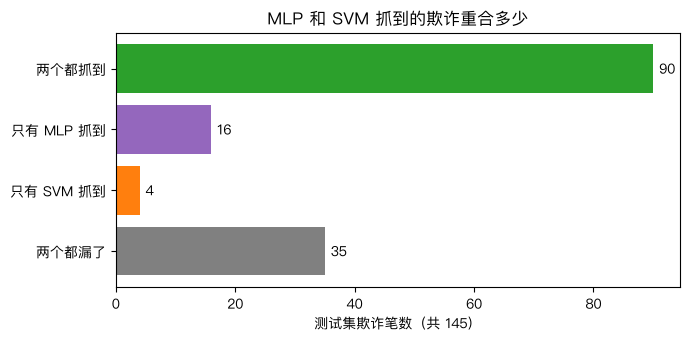

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(overlap.index[::-1], overlap.values[::-1], color=['gray', 'tab:orange', 'tab:purple', 'tab:green'])
for i, v in enumerate(overlap.values[::-1]):
    ax.text(v + 1, i, str(v), va='center')
ax.set_xlabel('测试集欺诈笔数（共 145）')
ax.set_title('MLP 和 SVM 抓到的欺诈重合多少')
plt.tight_layout()
plt.show()

## 2. 为什么第一级不好设：MLP 的分数是"两极分化"的

把测试集里两类交易的 MLP 分数画出来（横轴取对数）。
看什么：欺诈交易要么分数很高（MLP 很有把握），要么分数几乎是 0（MLP 完全没认出来），中间很少。所以第一级想多放进几笔欺诈时，阈值会从 0.7 左右一下子掉到接近 0，放进来的交易数量会突然暴增。上面诊断里"两个都漏了"的那批欺诈，大多就在分数接近 0 的那一堆里。

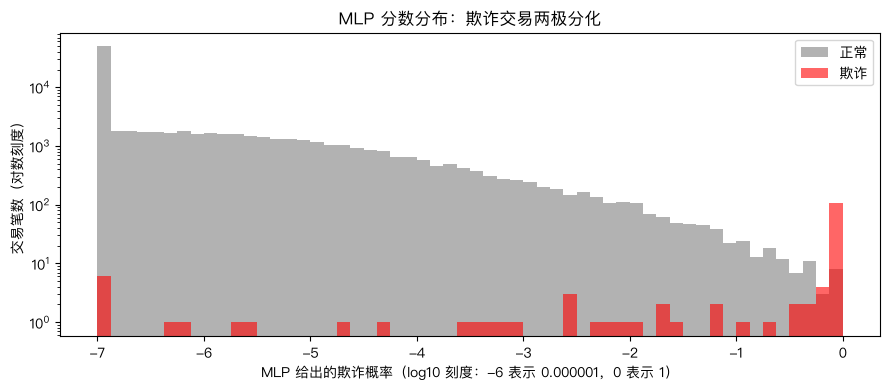

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-7, 0, 57)
for c, name, color in [(0, '正常', 'gray'), (1, '欺诈', 'red')]:
    ax.hist(np.log10(np.clip(p_test[y_test == c], 1e-7, 1)), bins=bins, alpha=0.6, color=color, label=name)
ax.set_yscale('log')
ax.set_xlabel('MLP 给出的欺诈概率（log10 刻度：-6 表示 0.000001，0 表示 1）')
ax.set_ylabel('交易笔数（对数刻度）')
ax.set_title('MLP 分数分布：欺诈交易两极分化')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 分级筛查：第一级放宽到什么程度

第一级的阈值按"在验证集上至少抓到 R 比例的欺诈"来定，R 取 0.80、0.85、0.90、0.95 四档，每档都完整跑一遍两级流程。

第二级 SVM 要在"被第一级放进来的训练样本"上训练。但 MLP 给自己训练过的样本打分会偏高，用这种分数挑出来的训练子集，和测试时会遇到的子集不一样。所以用 **5 折交叉预测**：拟合数据分 5 份，每次用 4 份训练一个 MLP、给剩下 1 份打分；完全相同的行放在同一折里，原则和 02 一样。

第二级有两种做法：
- **只看 SVM**：子集里完全按 SVM 的复核结果排序；
- **MLP 与 SVM 平均**：子集里把两者校准后的概率取平均——相当于"只在 MLP 拿不准的区域里做并行组合"。

第二级 SVM 只用子集里的数据，一条都不抽样；在子集上重新标准化，并在验证子集上挑 C 和 gamma。大约要几分钟（R=0.95 时子集最大，最慢）。

In [7]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def platt(score_val, y, score_test):
    m = LogisticRegression().fit(score_val.reshape(-1, 1), y)
    return m.predict_proba(score_val.reshape(-1, 1))[:, 1], m.predict_proba(score_test.reshape(-1, 1))[:, 1]

def cascade(p, passed, s2):
    out = p.copy()
    out[passed] = 1 + s2
    return out

oof = np.zeros(len(y_fit))
for tr_i, te_i in StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_fit, y_fit, groups_fit):
    oof[te_i] = make_mlp().fit(X_fit[tr_i], y_fit[tr_i]).predict_proba(X_fit[te_i])[:, 1]
val_fraud_scores = np.sort(p_val[y_val == 1])[::-1]

sweep, kept = [], {}
for R in [0.80, 0.85, 0.90, 0.95]:
    t1 = val_fraud_scores[int(np.ceil(R * len(val_fraud_scores))) - 1]
    pf, pv, pt = oof >= t1, p_val >= t1, p_test >= t1
    scaler = StandardScaler().fit(X_fit[pf])
    A_fit, A_val, A_test = scaler.transform(X_fit[pf]), scaler.transform(X_val[pv]), scaler.transform(X_test[pt])
    start = time.time()
    best = None
    for C, gamma in itertools.product([1, 10, 100], ['scale', 0.003, 0.01, 0.03]):
        m = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=42).fit(A_fit, y_fit[pf])
        ap = average_precision_score(y_val[pv], m.decision_function(A_val))
        if best is None or ap > best[0]:
            best = (ap, m, C, gamma)
    _, m, C, gamma = best
    svm_v, svm_t = platt(m.decision_function(A_val), y_val[pv], m.decision_function(A_test))
    mlp_v, mlp_t = platt(logit(p_val[pv]), y_val[pv], logit(p_test[pt]))
    stage2 = {'只看 SVM': (svm_v, svm_t), 'MLP 与 SVM 平均': ((svm_v + mlp_v) / 2, (svm_t + mlp_t) / 2)}
    for how, (s2v, s2t) in stage2.items():
        val_score, test_score = cascade(p_val, pv, s2v), cascade(p_test, pt, s2t)
        row = summary(f'级联 R={R:.2f}，{how}', y_test, test_score, best_f1_threshold(y_val, val_score))
        row.update({'R': R, '第二级做法': how, '验证集 AUPRC（用来挑）': average_precision_score(y_val, val_score),
                    '第一级阈值': t1, '测试集进入第二级': int(pt.sum()), '进入比例': pt.mean(),
                    '子集欺诈比例': y_test[pt].mean(),
                    '子集内 AUPRC：MLP': average_precision_score(y_test[pt], p_test[pt]),
                    '子集内 AUPRC：SVM': average_precision_score(y_test[pt], svm_t),
                    '子集内 AUPRC：平均': average_precision_score(y_test[pt], (svm_t + mlp_t) / 2),
                    'SVM 训练样本数': int(pf.sum()), 'SVM 网格耗时(秒)': time.time() - start})
        sweep.append(row)
        kept[row['方案']] = test_score
    print(f'R={R:.2f}：第一级阈值 {t1:.4f}，测试集 {pt.sum()} 笔（{pt.mean():.2%}）进入第二级，其中欺诈 {y_test[pt].sum()} 笔；SVM 最优 C={C}，gamma={gamma}')

sweep = pd.DataFrame(sweep).set_index('方案')
sweep.groupby('R')[['第一级阈值', '测试集进入第二级', '进入比例', '子集欺诈比例', '子集内 AUPRC：MLP', '子集内 AUPRC：SVM', '子集内 AUPRC：平均']].first().round(4)

R=0.80：第一级阈值 0.8774，测试集 109 笔（0.13%）进入第二级，其中欺诈 102 笔；SVM 最优 C=100，gamma=0.01
R=0.85：第一级阈值 0.7234，测试集 114 笔（0.13%）进入第二级，其中欺诈 106 笔；SVM 最优 C=10，gamma=scale


R=0.90：第一级阈值 0.0005，测试集 2542 笔（2.98%）进入第二级，其中欺诈 130 笔；SVM 最优 C=10，gamma=0.01


R=0.95：第一级阈值 0.0000，测试集 19455 笔（22.78%）进入第二级，其中欺诈 136 笔；SVM 最优 C=10，gamma=0.003


,第一级阈值,测试集进入第二级,进入比例,子集欺诈比例,子集内 AUPRC：MLP,子集内 AUPRC：SVM,子集内 AUPRC：平均
R,,,,,,,
0.80,0.8774,109,0.0013,0.9358,0.9882,0.9896,0.9899
0.85,0.7234,114,0.0013,0.9298,0.9860,0.9930,0.9914
0.90,0.0005,2542,0.0298,0.0511,0.8907,0.8939,0.9064
0.95,0.0000,19455,0.2278,0.0070,0.8527,0.7779,0.8614


上表看的是第二级的"本职工作"：只看被放进来的那批测试交易，在这批里谁排得更准。
- 放得很严时（R=0.80、0.85），进来的一百来笔几乎全是欺诈（九成以上），MLP 自己已经排得近乎完美，第二级没什么可做的；
- 放宽到 R=0.90、0.95，进来的是几千到上万笔真正的"难样本"，这时看 SVM 和平均分是不是比 MLP 自己更准。

## 4. 整条流水线的成绩

每一档 R、每种第二级做法都算一遍；用**验证集** AUPRC 挑出最好的那个组合（不看测试集），再和单独 MLP 比。

In [8]:
chosen = sweep['验证集 AUPRC（用来挑）'].idxmax()
print('按验证集挑出的级联配置：', chosen)

final = pd.concat([
    pd.DataFrame([summary('单独 MLP', y_test, p_test, t_mlp)]).set_index('方案'),
    sweep[['AUPRC', 'F1', '抓到', '漏掉', '误报', 'Recall', 'Precision', '验证集 AUPRC（用来挑）']],
    pd.DataFrame([summary('单独 SVM（调参后）', y_test, s_test, t_svm)]).set_index('方案'),
])
final.to_csv(f'{DATA_DIR}/results_cascade.csv')

start = time.perf_counter(); mlp.predict_proba(X_test); t_mlp_inf = time.perf_counter() - start
start = time.perf_counter(); svm.decision_function(X_test); t_svm_inf = time.perf_counter() - start
print(f'推理耗时参考：单独 MLP {t_mlp_inf:.3f} 秒；单独 SVM {t_svm_inf:.3f} 秒（级联只对进入第二级的那部分跑 SVM）')
final.round(4)

按验证集挑出的级联配置： 级联 R=0.85，只看 SVM


推理耗时参考：单独 MLP 0.033 秒；单独 SVM 7.041 秒（级联只对进入第二级的那部分跑 SVM）


,AUPRC,F1,抓到,漏掉,误报,Recall,Precision,验证集 AUPRC（用来挑）
方案,,,,,,,,
单独 MLP,0.8000,0.8185,106,39,8,0.7310,0.9298,NaN
级联 R=0.80，只看 SVM,0.8010,0.8185,106,39,8,0.7310,0.9298,0.8738
级联 R=0.80，MLP 与 SVM 平均,0.8012,0.8185,106,39,8,0.7310,0.9298,0.8726
级联 R=0.85，只看 SVM,0.8051,0.8127,102,43,4,0.7034,0.9623,0.8778
级联 R=0.85，MLP 与 SVM 平均,0.8040,0.8268,105,40,4,0.7241,0.9633,0.8778
级联 R=0.90，只看 SVM,0.8028,0.8108,105,40,9,0.7241,0.9211,0.8544
级联 R=0.90，MLP 与 SVM 平均,0.8141,0.8222,111,34,14,0.7655,0.8880,0.8727
级联 R=0.95，只看 SVM,0.7298,0.7105,108,37,51,0.7448,0.6792,0.7901
级联 R=0.95，MLP 与 SVM 平均,0.8082,0.8000,100,45,5,0.6897,0.9524,0.8577


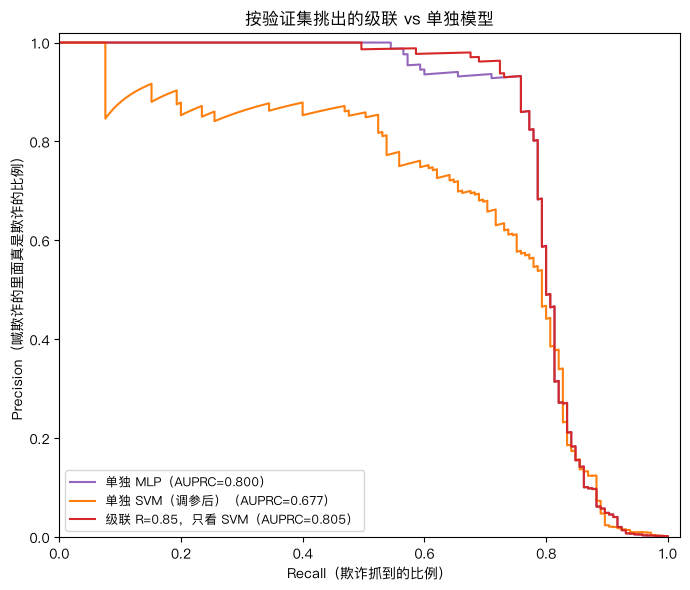

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, s, color in [('单独 MLP', p_test, 'tab:purple'),
                       ('单独 SVM（调参后）', s_test, 'tab:orange'),
                       (chosen, kept[chosen], 'tab:red')]:
    p, r, _ = precision_recall_curve(y_test, s)
    ax.plot(r, p, color=color, label=f'{name}（AUPRC={average_precision_score(y_test, s):.3f}）')
ax.set_xlabel('Recall（欺诈抓到的比例）')
ax.set_ylabel('Precision（喊欺诈的里面真是欺诈的比例）')
ax.set_title('按验证集挑出的级联 vs 单独模型')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

## 看完之后记下来（用你自己的话）

1. 诊断：MLP 和 SVM 漏掉的欺诈重合多少？"只有 SVM 抓到"的有几笔？这能不能解释 05 里组合没用？
2. 或规则、与规则分别是怎么"换"的：多抓几笔，要付出多少误报？
3. 第一级放进来多少笔、子集里欺诈比例多高？和全量的 0.17% 比，SVM 面对的问题变了多少？
4. MLP 分数为什么两极分化？这对"第一级阈值"意味着什么？
5. 第一级放得严和放得宽时，第二级各自在干什么？在难样本子集里，SVM 或平均分有没有比 MLP 自己更准？
6. 按验证集挑出的级联，和单独 MLP 比赢了多少？这个差距和"测试集只有 145 笔欺诈"的噪声比，算不算可靠？
7. 这些怎么回答思考题 1、2：SVM 适合放在哪个环节？组合在什么条件下才有用？